<a href="https://colab.research.google.com/github/gyumin125/25-2-DIP-202302456/blob/main/HW/HW11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import transforms
from torchvision.transforms import v2
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder, DatasetFolder
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix


In [2]:
if torch.cuda.is_available():
  device = torch.device('cuda:0')
else:
  device = torch.device('cpu')

print(device)

cuda:0


## Download MNIST and Prepare Data Loader

1. Data Loader를 따로 정의 : Traning data, validation data 불러오는 과정 구분함.  
공통점으로는 model에 적합한 형태로 transform해줌. (size, intensity range 등)  
차이점으로 training은 argumentation을 더 해줘야함. 있을법한 변화를 주어야함(random)하게

In [3]:
path0 = '.'

transform = v2.Compose(
    [
        v2.ToTensor(),
        v2.Grayscale(),
        v2.ToDtype(torch.float32, scale=True),  # Normalize expects float input
        v2.RandomCrop(size=(28, 28)),
        ]
    )

transform_val = v2.Compose(
    [
        v2.ToTensor(), #np.array같은 class임.
        v2.Grayscale(),
        v2.ToDtype(torch.float32, scale=True),  # Normalize expects float input, type 통일
        v2.CenterCrop(size=(28, 28)),
        ]
    )

mnist_train = torchvision.datasets.MNIST(path0, train=True, transform=transform, target_transform=None, download=True)
mnist_valid = torchvision.datasets.MNIST(path0, train=False, transform=transform_val, target_transform=None, download=True)
def get_mnist_labels(labels):
    text_labels = ['0', '1', '2', '3', '4',
                   '5', '6', '7', '8', '9']
    return [text_labels[int(i)] for i in labels]

# defining data_iter, linreg. model, loss, sgd
batch_size = 100
num_workers = 0
train_iter = DataLoader(mnist_train, batch_size, shuffle=True, num_workers=num_workers) #batch size는 모델에 한번에 넣을 갯수이자 parameter업데이트 단위
valid_iter = DataLoader(mnist_valid, batch_size, shuffle=False, num_workers=num_workers) #shuffle은 model에 data넣을때 순서대로가 아닌(1-100,100-200 ~), epoch마다 섞어서 진행하게 됨. shuffle안하면 gradient가 주기적인 패턴을 가져서 학습이 비효율적이게 됨. validation은 업데이트 용이 아니라 셔플 안해도 됨.

/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


In [4]:
mnist_train

Dataset MNIST
    Number of datapoints: 60000
    Root location: .
    Split: Train
    StandardTransform
Transform: Compose(
                 ToTensor()
                 Grayscale(num_output_channels=1)
                 ToDtype(scale=True)
                 RandomCrop(size=(28, 28), pad_if_needed=False, fill=0, padding_mode=constant)
           )

In [5]:
mnist_valid

Dataset MNIST
    Number of datapoints: 10000
    Root location: .
    Split: Test
    StandardTransform
Transform: Compose(
                 ToTensor()
                 Grayscale(num_output_channels=1)
                 ToDtype(scale=True)
                 CenterCrop(size=(28, 28))
           )

torch.Size([100])
torch.Size([100, 1, 28, 28])


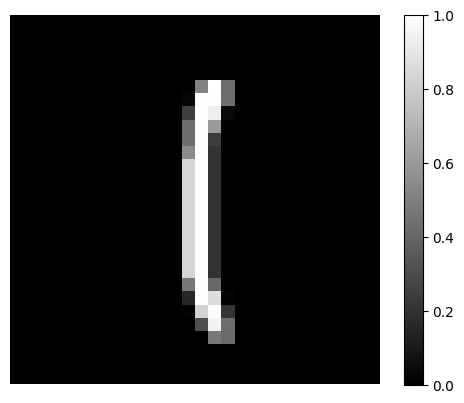

['1']


In [6]:
for images, labels in train_iter:
  print(labels.shape)
  print(images.shape)
  I = images[0].numpy()
  plt.figure(dpi=100)
  plt.imshow(I[0],cmap='gray')
  plt.axis('off')
  plt.colorbar()
  plt.show()
  print(get_mnist_labels([labels[0]]))
  break

## illustration of torchivision transforms
torchvision에서 제공하는 다양한 transform들을 적절히 transform (data augmentation) 에 추가하여 model의 generality를 높이자.
https://pytorch.org/vision/main/transforms.html


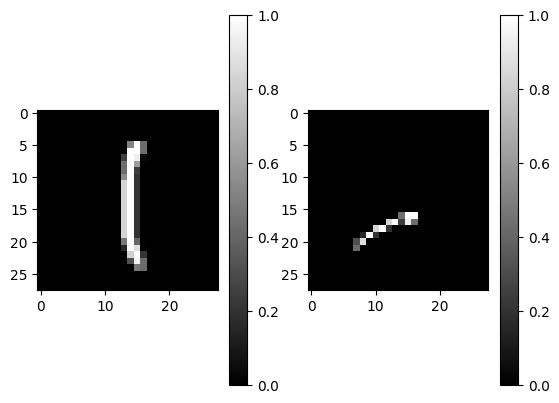

In [7]:
t_imges = v2.RandomAffine(degrees=(30, 70), translate=(0.1, 0.3), scale=(0.5, 0.75))(images) #random affine의 degree.
plt.subplot(121)
plt.imshow(images[0,0],cmap='gray')
plt.colorbar()
plt.subplot(122)
plt.imshow(t_imges[0,0],cmap='gray')
plt.colorbar()
plt.show()

In [8]:
transform = v2.Compose(
    [
        v2.ToTensor(),
        v2.Grayscale(),
        v2.ToDtype(torch.float32, scale=True),  # Normalize expects float input

        v2.RandomAffine(degrees=30, translate=(0.2,0.2), scale=(0.7,1.3),shear=(-20, 20)),# <-- add your transforms
        v2.ColorJitter(brightness=0.5, contrast=0.5),
        v2.RandomCrop(size=(28, 28)),
        ]
    )

이거 추가하는게 정확도 높이는데 좀 큰 영향 끼칠 것임.

## Network
- 강의노트의 LeNet architecture를 기반으로 CNN model을 정의하기

LeNet은 순차적으로 정의만해주면 됨. 새로운 layer추가는 안되고, hyperparameter만 변하는 거 허용. 또한 activation이나 pooling을 다른 거로 변경만 가능. architecture유지 해야함.(Avpool->Maxpool, ReLu->sigmoid 뭐 이런식)

In [9]:
net = torch.nn.Sequential(
    nn.Conv2d(in_channels=1, out_channels=64, kernel_size=5, padding=2),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Conv2d(in_channels=64, out_channels=128, kernel_size=5,padding=2),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    nn.Linear(in_features=128*7*7, out_features=512),
    nn.ReLU(),
    nn.Linear(512, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
)
net = net.to(device)
net

Sequential(
  (0): Conv2d(1, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(64, 128, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Flatten(start_dim=1, end_dim=-1)
  (7): Linear(in_features=6272, out_features=512, bias=True)
  (8): ReLU()
  (9): Linear(in_features=512, out_features=128, bias=True)
  (10): ReLU()
  (11): Linear(in_features=128, out_features=10, bias=True)
)

- (1, 1, 28, 28) 크기로 정의한 input이 각각의 layer에서 어떤 크기로 변환되는 지를 확인하고 이해하자.

(batch size , channel, 28,28)

In [10]:
X = torch.randn(size=(1,1,28,28), dtype = torch.float32)
X = X.to(device)
for layer in net:
    X = layer(X)
    print(layer.__class__.__name__,'output shape: \t',X.shape)

Conv2d output shape: 	 torch.Size([1, 64, 28, 28])
ReLU output shape: 	 torch.Size([1, 64, 28, 28])
MaxPool2d output shape: 	 torch.Size([1, 64, 14, 14])
Conv2d output shape: 	 torch.Size([1, 128, 14, 14])
ReLU output shape: 	 torch.Size([1, 128, 14, 14])
MaxPool2d output shape: 	 torch.Size([1, 128, 7, 7])
Flatten output shape: 	 torch.Size([1, 6272])
Linear output shape: 	 torch.Size([1, 512])
ReLU output shape: 	 torch.Size([1, 512])
Linear output shape: 	 torch.Size([1, 128])
ReLU output shape: 	 torch.Size([1, 128])
Linear output shape: 	 torch.Size([1, 10])


## Hyperparameters
- learning rate, number of epochs, loss function, algorithm 을 적절하게 정의하기

loss function과 algorithm은 건드리지 말고, learning_rate랑 epoch만 변경

In [11]:

# setting hyper-parameters
learning_rate = 0.001
num_epochs = 50

# loss function and algorithm. 안배워서 건들 X
loss = torch.nn.CrossEntropyLoss() # loss
alg = torch.optim.Adam(net.parameters(),lr=learning_rate) # sgd

## Train a Model
- training set/validation set를 활용하여 model을 학습시키기

주석 위치와 의미 좀 기억하면 좋을 듯?

epoch #: 0 train loss:  0.14525045454502106 train accuracy:  95.42666625976562 valid accuracy:  98.70999908447266
epoch #: 1 train loss:  0.03975867107510567 train accuracy:  98.7699966430664 valid accuracy:  98.98999786376953
epoch #: 2 train loss:  0.02558269165456295 train accuracy:  99.1816635131836 valid accuracy:  99.19999694824219


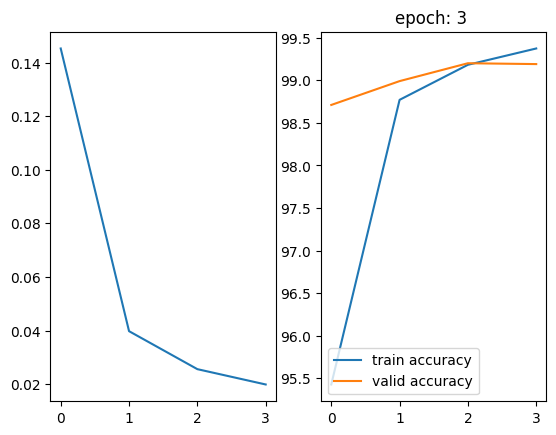

epoch #: 3 train loss:  0.019865330308675766 train accuracy:  99.37333679199219 valid accuracy:  99.19000244140625
epoch #: 4 train loss:  0.014460691250860691 train accuracy:  99.53333282470703 valid accuracy:  99.08999633789062
epoch #: 5 train loss:  0.013005347922444344 train accuracy:  99.56500244140625 valid accuracy:  99.0999984741211
epoch #: 6 train loss:  0.010300064459443092 train accuracy:  99.65499877929688 valid accuracy:  98.80999755859375
epoch #: 7 train loss:  0.00850596372038126 train accuracy:  99.73666381835938 valid accuracy:  99.16999816894531
epoch #: 8 train loss:  0.008421868085861206 train accuracy:  99.7300033569336 valid accuracy:  99.23999786376953
epoch #: 9 train loss:  0.005073110572993755 train accuracy:  99.85166931152344 valid accuracy:  99.11000061035156
epoch #: 10 train loss:  0.007864580489695072 train accuracy:  99.7683334350586 valid accuracy:  99.12999725341797


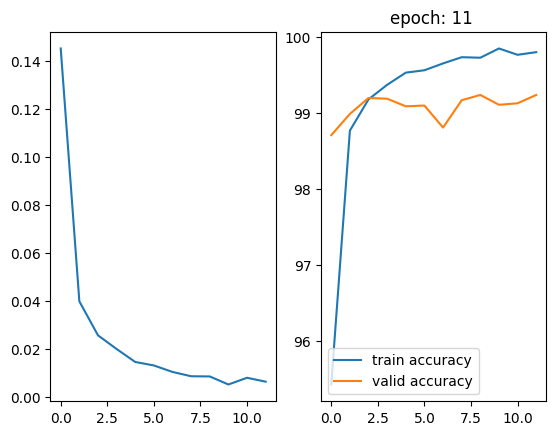

epoch #: 11 train loss:  0.00624596094712615 train accuracy:  99.80333709716797 valid accuracy:  99.23999786376953
epoch #: 12 train loss:  0.004363019950687885 train accuracy:  99.84666442871094 valid accuracy:  99.02999877929688
epoch #: 13 train loss:  0.005748845171183348 train accuracy:  99.84833526611328 valid accuracy:  99.31999969482422
epoch #: 14 train loss:  0.006166278384625912 train accuracy:  99.8316650390625 valid accuracy:  98.88999938964844
epoch #: 15 train loss:  0.0033931226935237646 train accuracy:  99.90333557128906 valid accuracy:  99.37999725341797
epoch #: 16 train loss:  0.0033320605289191008 train accuracy:  99.89666748046875 valid accuracy:  99.26000213623047
epoch #: 17 train loss:  0.002792277140542865 train accuracy:  99.9316635131836 valid accuracy:  99.30999755859375
epoch #: 18 train loss:  0.0050133829936385155 train accuracy:  99.84500122070312 valid accuracy:  99.20999908447266


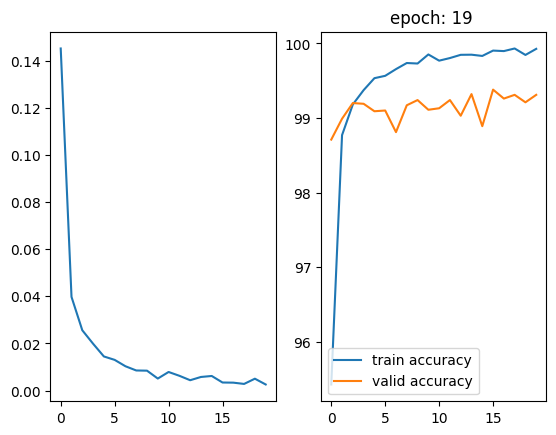

epoch #: 19 train loss:  0.0025579151697456837 train accuracy:  99.92666625976562 valid accuracy:  99.30999755859375
epoch #: 20 train loss:  7.927369006210938e-05 train accuracy:  100.0 valid accuracy:  99.41000366210938
epoch #: 21 train loss:  8.606108167441562e-06 train accuracy:  100.0 valid accuracy:  99.41000366210938
epoch #: 22 train loss:  3.838511474896222e-06 train accuracy:  100.0 valid accuracy:  99.4000015258789
epoch #: 23 train loss:  2.4421917714789743e-06 train accuracy:  100.0 valid accuracy:  99.4000015258789
epoch #: 24 train loss:  1.6068981949501904e-06 train accuracy:  100.0 valid accuracy:  99.4000015258789
epoch #: 25 train loss:  1.076952798939601e-06 train accuracy:  100.0 valid accuracy:  99.4000015258789
epoch #: 26 train loss:  7.178623491199687e-07 train accuracy:  100.0 valid accuracy:  99.4000015258789


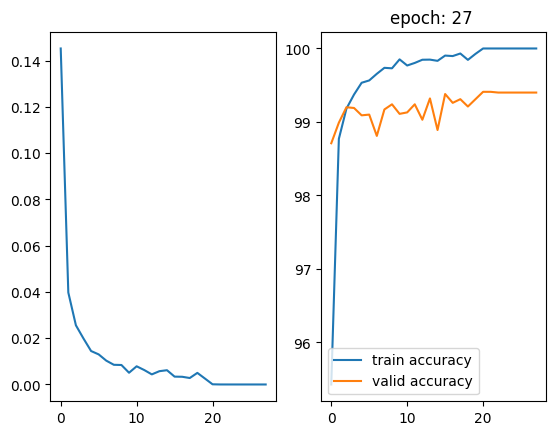

epoch #: 27 train loss:  4.806793754141836e-07 train accuracy:  100.0 valid accuracy:  99.4000015258789
epoch #: 28 train loss:  3.226247429211071e-07 train accuracy:  100.0 valid accuracy:  99.41000366210938
epoch #: 29 train loss:  2.164530883419502e-07 train accuracy:  100.0 valid accuracy:  99.41999816894531
epoch #: 30 train loss:  1.4608070841859444e-07 train accuracy:  100.0 valid accuracy:  99.41000366210938
epoch #: 31 train loss:  9.90550645951771e-08 train accuracy:  100.0 valid accuracy:  99.41000366210938
epoch #: 32 train loss:  6.785894868244213e-08 train accuracy:  100.0 valid accuracy:  99.41000366210938
epoch #: 33 train loss:  4.60500721999324e-08 train accuracy:  100.0 valid accuracy:  99.4000015258789
epoch #: 34 train loss:  3.047366448072353e-08 train accuracy:  100.0 valid accuracy:  99.41000366210938


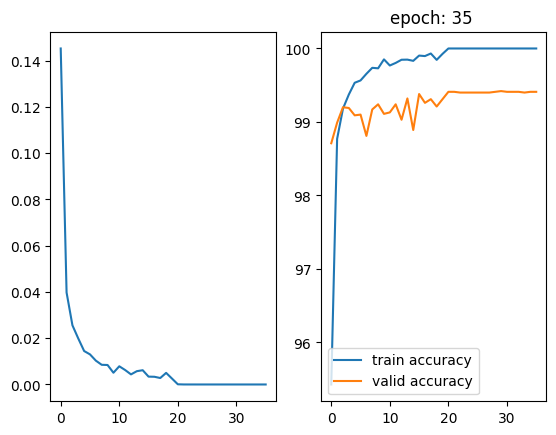

epoch #: 35 train loss:  2.0412510792766625e-08 train accuracy:  100.0 valid accuracy:  99.41000366210938
epoch #: 36 train loss:  1.417392958558139e-08 train accuracy:  100.0 valid accuracy:  99.4000015258789
epoch #: 37 train loss:  1.0061238064906775e-08 train accuracy:  100.0 valid accuracy:  99.4000015258789
epoch #: 38 train loss:  7.079039132662501e-09 train accuracy:  100.0 valid accuracy:  99.4000015258789
epoch #: 39 train loss:  5.100173616767734e-09 train accuracy:  100.0 valid accuracy:  99.41000366210938
epoch #: 40 train loss:  3.6358884791809487e-09 train accuracy:  100.0 valid accuracy:  99.41000366210938
epoch #: 41 train loss:  2.6742648095989807e-09 train accuracy:  100.0 valid accuracy:  99.41000366210938
epoch #: 42 train loss:  1.907350943852748e-09 train accuracy:  100.0 valid accuracy:  99.41000366210938


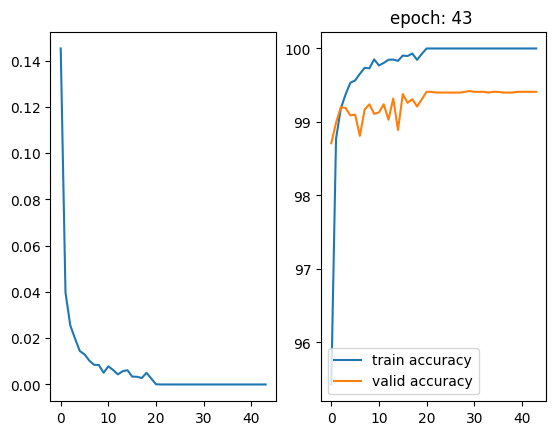

epoch #: 43 train loss:  1.4245523649591973e-09 train accuracy:  100.0 valid accuracy:  99.41000366210938
epoch #: 44 train loss:  1.0748714140973448e-09 train accuracy:  100.0 valid accuracy:  99.41000366210938
epoch #: 45 train loss:  7.708860771948878e-10 train accuracy:  100.0 valid accuracy:  99.41000366210938
epoch #: 46 train loss:  5.662436630693435e-10 train accuracy:  100.0 valid accuracy:  99.41000366210938
epoch #: 47 train loss:  4.251794749610127e-10 train accuracy:  100.0 valid accuracy:  99.41000366210938
epoch #: 48 train loss:  3.258384950743931e-10 train accuracy:  100.0 valid accuracy:  99.41000366210938
epoch #: 49 train loss:  2.2848434255706707e-10 train accuracy:  100.0 valid accuracy:  99.41000366210938


In [12]:
# training the model
loss_train = np.array([])
accs_train = np.array([])
accs_valid = np.array([])

for epoch in range(num_epochs):
  i=0
  l_epoch = 0
  correct = 0
  for X,y in train_iter: #train_iter가 data loader임
    i=i+1
    X,y = X.to(device),y.to(device) # GPU, X가 input y가 label
    alg.zero_grad()
    y_hat=net(X) #X라는 input을 모델에 넣어 y라는 output얻는 과정. forward propagation
    correct += (y_hat.argmax(dim=1)==y).sum()
    l=loss(y_hat,y) #loss 계산, 얼마나 잘 맞췄는지. 모델의 output과 label비교
    l_epoch+=l
    l.backward() #gradient계산. backpropagation
    alg.step() #parameter 업데이트

  loss_train = np.append(loss_train,l_epoch.cpu().detach().numpy()/i)
  accs_train = np.append(accs_train,(100*correct.cpu())/len(mnist_train))

  correct = 0
  for X,y in valid_iter:
    X,y = X.to(device),y.to(device)
    y_hat = net(X)
    correct += (y_hat.argmax(dim=1)==y).sum()

  accs_valid = np.append(accs_valid,(100*correct.cpu())/len(mnist_valid))

  if epoch%8 == 3:
    plt.subplot(121)
    plt.plot(loss_train,label='train loss')
    plt.subplot(122)
    plt.plot(accs_train,label='train accuracy')
    plt.plot(accs_valid,label='valid accuracy')
    plt.legend(loc='lower left')
    plt.title('epoch: %d '%(epoch))
    plt.show()

  print('epoch #:',epoch,'train loss: ',loss_train[-1],'train accuracy: ',accs_train[-1],'valid accuracy: ',accs_valid[-1])

위에 결과에 대해서 : learning rate에 따라서 accuracy가 달라짐. iid에 대해서는 정확도 너무 잘뽑힘

In [13]:
#torch.save(net.state_dict(),f'my_best_model.pth')

## Results (Validation Set)
- validation set에 대한 결과를 요약해보자.

In [14]:
i = 0
y_all=[]
y_hat_all=[]
for X,y in valid_iter:
  i=i+1
  X=X.to(device)
  y_hat = net(X)
  y_hat = y_hat.argmax(dim=1)
  y_all.append(y)
  y_hat_all.append(y_hat)
y_all = torch.cat(y_all,dim=0)
y_hat_all = torch.cat(y_hat_all,dim=0)

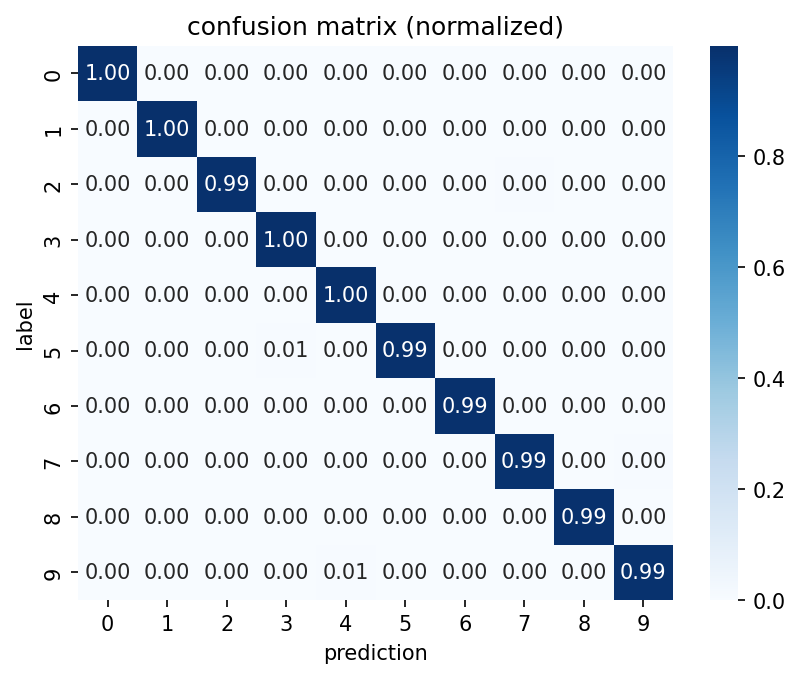

In [15]:
cf = confusion_matrix(y_all.numpy(),y_hat_all.cpu().numpy())
plt.figure(dpi=150)
cf = cf/np.sum(cf,axis=1)
sns.heatmap(cf,annot=True,cmap='Blues',fmt=".2f")
plt.title('confusion matrix (normalized)')
plt.ylabel('label')
plt.xlabel('prediction')
plt.show()

## Results (External Test Set)
- training set / validation set 과는 다른 방법으로 얻어진 데이터에 대해서 모델의 성능을 평가하고, 이에 대한 성능을 개선시킬 수 있는 방법을 고민하자.

과제 : 전에 작성한 data

In [16]:
!unzip hufs_mnist_2025 -d test

Archive:  hufs_mnist_2025.zip
replace test/easy/.DS_Store? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [17]:
transform_test = v2.Compose(
    [
        v2.Grayscale(),
        v2.Resize((32,32)),
        v2.CenterCrop(28),
        v2.ToTensor()
    ])

/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


In [26]:
from torchvision.datasets.places365 import path
path_test1 = 'test/easy' # replace with your path
data_test1= ImageFolder(root=path_test1,transform=transform_test)
path_test2 = 'test/hard' # replace with your path
data_test2= ImageFolder(root=path_test2,transform=transform_test)
#net.load_state_dict(torch.load(f'my_best_model.pth'))

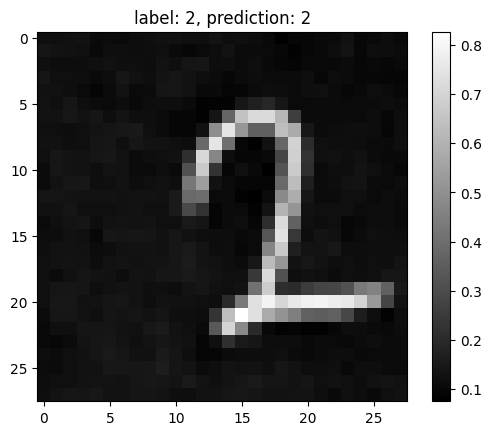

In [27]:
n=32
X = 1-data_test1[n][0].unsqueeze(0)
y = data_test1[n][1]
y_hat = net(X.to(device))
y_hat = y_hat.argmax(dim=1)
plt.imshow(X[0,0],cmap='gray')
plt.title(f'label: {y}, prediction: {y_hat.cpu().numpy()[0]}')
plt.colorbar()
plt.show()

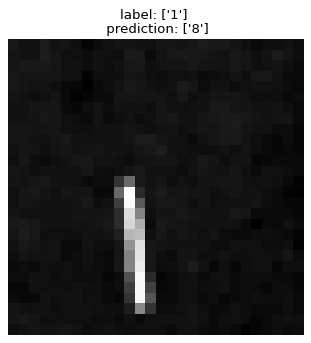

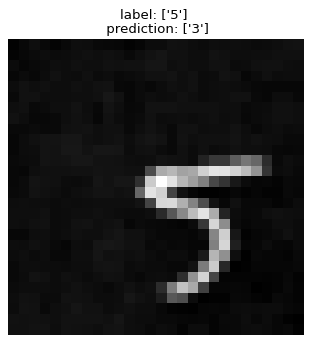

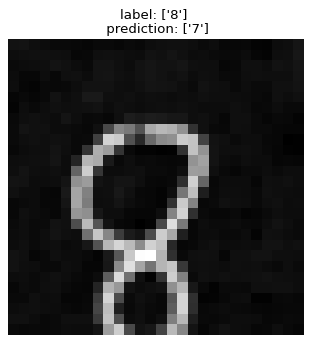

accuracy: 57.857142857142854
number of incorrect predictions: 59
number of correct predictions: 81


In [28]:
#len(data_test)
results1 = np.zeros((2,len(data_test1)))
num_incorrect = 0
flag_plot = 1
for n in range(len(data_test1)):
  X = 1 - data_test1[n][0].unsqueeze(0)
  y = data_test1[n][1]
  y_hat = net(X.to(device))
  y_hat = y_hat.argmax(dim=1)

  results1[0,n] = y
  results1[1,n] = y_hat
  if y_hat != y:
    num_incorrect+=1
    if num_incorrect%16==0:
      if flag_plot == 1:
        plt.figure(dpi=80)
        plt.imshow(X[0].cpu().squeeze(),cmap='gray')
        plt.title('label: %s \n prediction: %s'%(get_mnist_labels([y]),get_mnist_labels([y_hat])))
        plt.axis('off')
        plt.show()

acc = 100*(len(data_test1)-num_incorrect)/len(data_test1)
print(f'accuracy: {acc}')
print(f'number of incorrect predictions: {num_incorrect}')
print(f'number of correct predictions: {len(data_test1)-num_incorrect}')

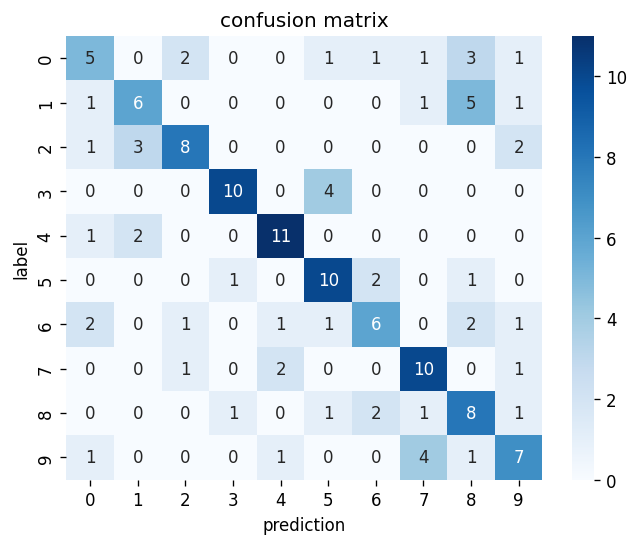

In [29]:
cf = confusion_matrix(results1[0,:],results1[1,:])
plt.figure(dpi=120)
sns.heatmap(cf,annot=True,cmap='Blues')
plt.title('confusion matrix')
plt.ylabel('label')
plt.xlabel('prediction')
plt.show()

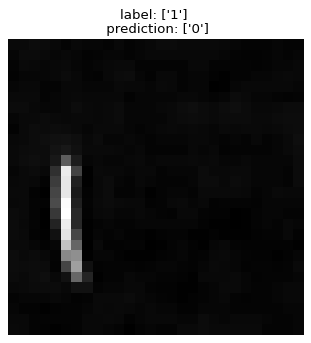

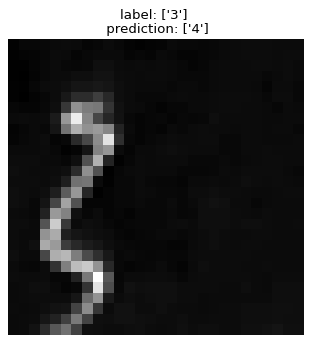

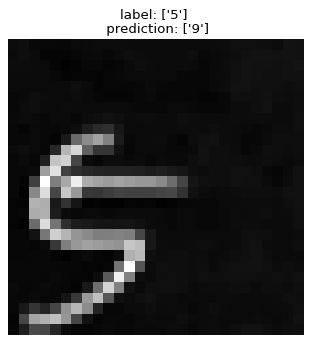

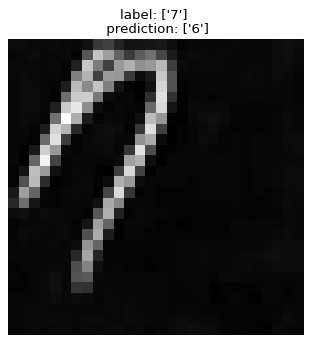

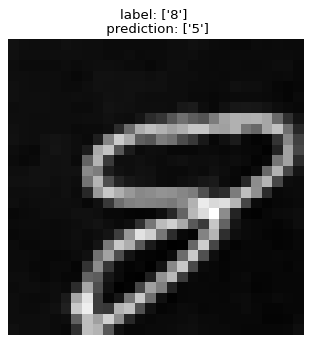

accuracy: 34.285714285714285
number of incorrect predictions: 92
number of correct predictions: 48


In [30]:
results2 = np.zeros((2,len(data_test2)))
num_incorrect=0
flag_plot = 1
for n in range(len(data_test2)):
  X = 1 - data_test2[n][0].unsqueeze(0)
  y = data_test2[n][1]
  y_hat = net(X.to(device))
  y_hat = y_hat.argmax(dim=1)

  results2[0,n] = y
  results2[1,n] = y_hat
  if y_hat != y:
    num_incorrect+=1
    if num_incorrect%16==0:
      if flag_plot == 1:
        plt.figure(dpi=80)
        plt.imshow(X[0].cpu().squeeze(),cmap='gray')
        plt.title('label: %s \n prediction: %s'%(get_mnist_labels([y]),get_mnist_labels([y_hat])))
        plt.axis('off')
        plt.show()

acc = 100*(len(data_test1)-num_incorrect)/len(data_test2)
print(f'accuracy: {acc}')
print(f'number of incorrect predictions: {num_incorrect}')
print(f'number of correct predictions: {len(data_test1)-num_incorrect}')

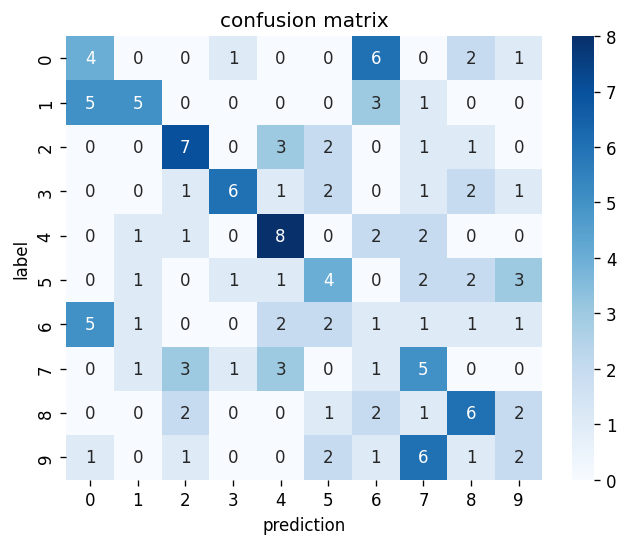

In [31]:
cf = confusion_matrix(results2[0,:],results2[1,:])
plt.figure(dpi=120)
sns.heatmap(cf,annot=True,cmap='Blues')
plt.title('confusion matrix')
plt.ylabel('label')
plt.xlabel('prediction')
plt.show()

## Homework
- transform, model, hyperparameter 등을 적절하게 수정하여 external test set에 대한 accuracy를 높여보자.

training data에는 mnist data만 이용해야하고, validation에 우리 data이용해야함.easy에 대해서는 50%이상, hard에 대해서는 30%이상